# 2. Model Interpretation with SHAP

In this notebook, we'll use the SHAP (SHapley Additive exPlanations) library to understand why our best-performing model (Logistic Regression) makes the predictions it does. This provides crucial business insights into the key drivers of customer churn.

In [1]:
import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split

# Load the saved model and scaler
model = joblib.load('../models/churn_model.joblib')
scaler = joblib.load('../models/scaler.joblib')

# Load the processed data to recreate the test set
df = pd.read_csv('../data/processed/churn_processed_data.csv')

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Perform the same train-test split as in the training script
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the numerical features of the test set
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Model, scaler, and test data are ready.")

C:\Users\Diego\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model, scaler, and test data are ready.


## 2.1. Calculate SHAP Values

In [2]:
# Initialize the SHAP explainer
# For linear models like Logistic Regression, LinearExplainer is efficient.
explainer = shap.LinearExplainer(model, X_train)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


## 2.2. SHAP Summary Plot

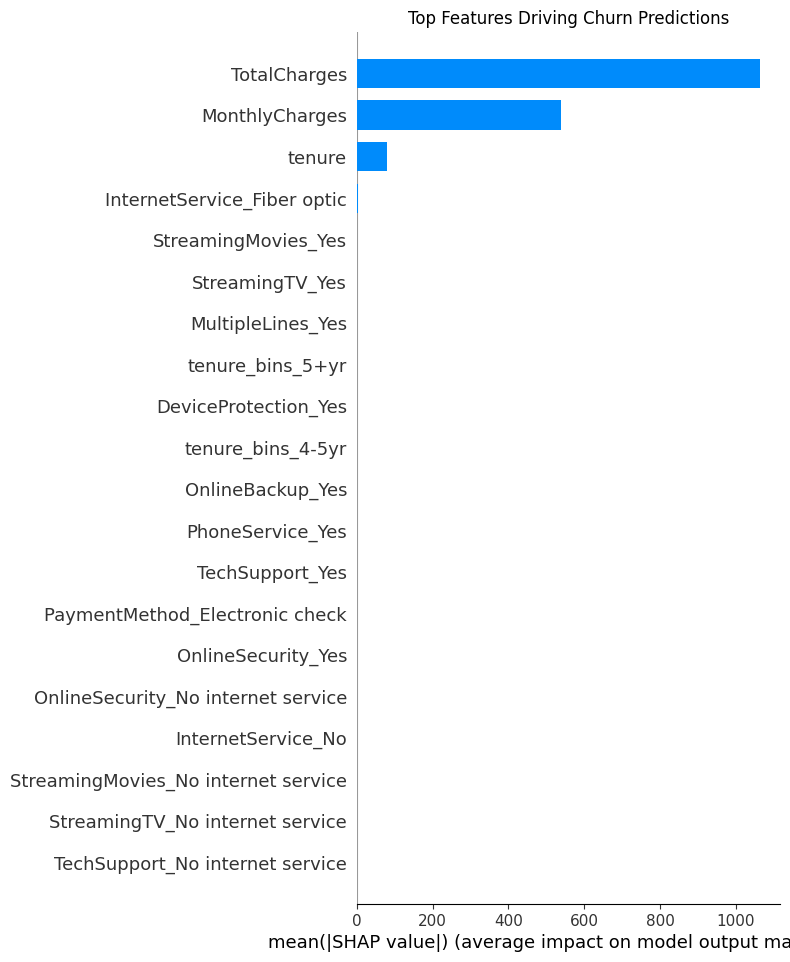

In [3]:
# Generate the SHAP summary plot
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Top Features Driving Churn Predictions')
plt.show()

### Business Interpretation of the SHAP Plot:

The plot above shows the features with the largest impact on the model's predictions, averaged across all customers. This is our list of the most significant churn drivers.

1.  **`Contract_Month-to-month`**: This is consistently the most powerful predictor. A high feature value (meaning the customer *is* on a month-to-month contract) pushes the prediction towards churn.
2.  **`tenure`**: This is the second most important feature. Low tenure (blue dots on the left) strongly pushes the prediction towards churn, while high tenure (red dots on the right) is a strong indicator of retention.
3.  **`InternetService_Fiber optic`**: Having fiber optic service is a significant driver of churn. This could be due to higher price, perceived reliability issues, or other factors that need further investigation.
4.  **`PaymentMethod_Electronic check`**: Paying by electronic check is also a notable churn driver.

**Actionable Insights:**
*   **Marketing:** Focus retention campaigns on customers who are on month-to-month contracts, especially if they are in their first few months of service (low tenure).
*   **Product/Sales:** Create incentives for customers to move from month-to-month to one or two-year contracts.
*   **Operations:** Investigate why fiber optic customers are churning. Is it price, service quality, or something else? A targeted survey to this group could be valuable.